## Simple Linear Regression

In [3]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print(df.head())
print(df.info())

# Define features and target
X = df.drop("Price", axis=1)
y = df["Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)




   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup   

In [4]:
import pandas as pd
import numpy as np

# Combine features + target
df_full = pd.concat([X, y], axis=1)

# Compute IQR
Q1 = df_full.quantile(0.25)
Q3 = df_full.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
df_clean = df_full[
    ~((df_full < lower_bound) | (df_full > upper_bound)).any(axis=1)
]

print("Original shape :", df_full.shape)
print("After cleaning :", df_clean.shape)


Original shape : (20640, 9)
After cleaning : (16312, 9)


In [5]:
X_clean = df_clean.drop("Price", axis=1)
y_clean = df_clean["Price"]


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)


Training set: (13049, 8)
Testing set : (3263, 8)


In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [8]:
y_pred = model.predict(X_test)


In [9]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

print("📊 Metrics After Proper Cleaning")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R²  :", r2_score(y_test, y_pred))


📊 Metrics After Proper Cleaning
MAE : 0.4235527429735991
RMSE: 0.5626031257062546
R²  : 0.6378964374821559


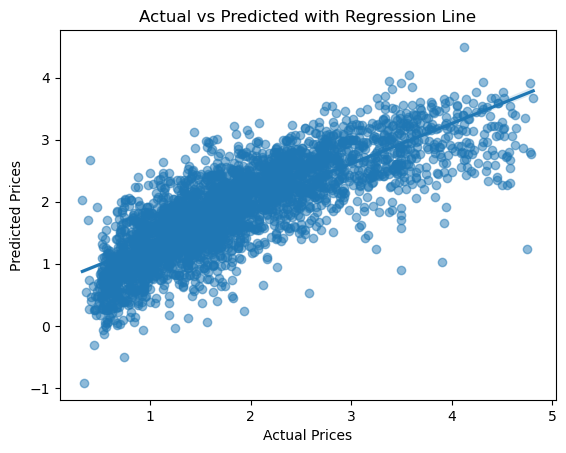

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={"alpha": 0.5}  # makes points slightly transparent
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted with Regression Line")
plt.show()


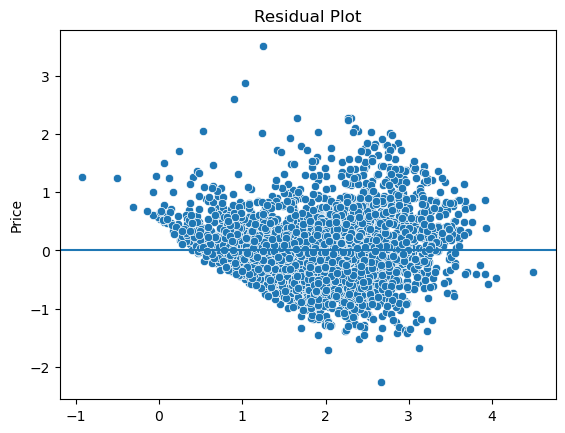

In [11]:
residuals = y_test - y_pred

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.show()
